In [2]:
# Carga de datos, info(), describe(), gestión de nulos (que no tienes), outliers y todas las gráficas (Pairplot, Heatmap, etc.).

# PROYECTO: Logística Predictiva
## Optimizando la Entrega en E-commerce para Proteger la Reputación de Marca

### 1. Contexto del Proyecto
Una empresa internacional de comercio electrónico especializada en productos tecnológicos desea extraer conocimientos clave de su base de datos de clientes. El objetivo es aplicar técnicas avanzadas de **Machine Learning** para analizar el comportamiento de sus usuarios y optimizar sus operaciones, centrándose en la puntualidad de las entregas.

### 2. Contenido del Dataset
El conjunto de datos utilizado consta de **10.999 observaciones** y **12 variables**. A continuación, se detalla la información contenida en cada columna:

* **ID**: Número de identificación del cliente.
* **Warehouse block (Bloque del almacén)**: El almacén principal está dividido en bloques (A, B, C, D, E).
* **Mode of shipment (Modo de envío)**: Método de transporte (Barco, Avión o Carretera).
* **Customer care calls (Llamadas a atención al cliente)**: Número de consultas realizadas por el cliente sobre su envío.
* **Customer rating (Valoración)**: Calificación del cliente (1: peor, 5: mejor).
* **Cost of the product (Coste)**: Precio del producto en USD.
* **Prior purchases (Compras previas)**: Número de pedidos anteriores del cliente.
* **Product importance (Importancia)**: Categorización del producto (baja, media, alta).
* **Gender (Género)**: Sexo del cliente (Masculino/Femenino).
* **Discount offered (Descuento)**: Rebaja aplicada al producto.
* **Weight in gms (Peso)**: Peso físico del paquete en gramos.
* **Reached on time (Llegada a tiempo)**: **Variable objetivo (Target)**. El valor **1** indica que el producto **NO** llegó a tiempo (retraso), mientras que el **0** indica que llegó a tiempo.

### 3. Análisis Inicial y Objetivos de Negocio

#### Estructura de los datos (Resumen de df.info()):
- **Volumen**: 10.999 registros y 12 campos (cumple con los requisitos del proyecto).
- **Calidad**: No se detectan valores nulos iniciales, lo que permite un flujo de trabajo de limpieza directo.
- **Tipos**: Mezcla de variables categóricas (objetos) y numéricas (enteros), lo que requerirá preprocesamiento y *encoding* posterior.

#### Preguntas de Investigación (Business Case):
1. ¿Existe un "cuello de botella" logístico en algún bloque de almacén específico?
2. ¿Qué modo de envío presenta la mayor tasa de incumplimiento?
3. ¿Cómo influye el peso y el coste del producto en la prioridad de entrega?
4. ¿Existe una correlación entre los descuentos agresivos y los retrasos en los envíos?
5. ¿Podemos predecir un retraso antes de que ocurra para emitir una alerta proactiva al cliente?

#### Estado de la Variable Objetivo:
Tras un análisis inicial, se observa que:
- **1 (Retraso)**: 59.7%
- **0 (A tiempo)**: 40.3%
*Conclusión*: La empresa tiene una tasa de retraso muy elevada. El modelo se enfocará en detectar ese 60% de fallos para que el equipo de atención al cliente pueda actuar de forma preventiva[cite: 2].

In [3]:
# Tratamiento de datos
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
#from sklearn.decomposition import PCA
#from sklearn.pipeline import make_pipeline
#from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import scale

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("../data/shipping_data.csv")

df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [5]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [7]:
# observaciones: 10.999 registros

# cols: 12 variables

# no se detectan valores nulos

# tipos de datos:
# object (veriables categóricas): Warehouse_block, Mode_of_Shipment, Product_importance, Gender.
# int64: ID, Customer_care_calls, Customer_rating, Cost_of_the_Product, Prior_purchases, Discount_offered, Weight_in_gms

# target: Reached.on.Time_Y.N (Binaria: 0 o 1).


In [8]:
# me pregunto:

# ¿existe un 'cuello de botella' en algún almacén (Warehouse_block) específico?
# ¿el modo de envío (avión, barco, carretera) influye proporcionalmente en los retrasos?
# ¿los clientes con más compras previas (fidelizados) reciben mejor servicio o sufren más retrasos?
# ¿hay una correlación entre el peso del producto y la probabilidad de llegar tarde?
# ¿cómo impacta el descuento ofrecido? ¿los productos muy rebajados se priorizan menos?

In [9]:
# esto te dirá cuántos paquetes llegaron tarde (1) y cuántos a tiempo (0)
df['Reached.on.Time_Y.N'].value_counts(normalize=True).sort_index() * 100

# .sort_index() ordena las filas basándose en las etiquetas (el 0 y el 1) en lugar de los valores

Reached.on.Time_Y.N
0    40.330939
1    59.669061
Name: proportion, dtype: float64

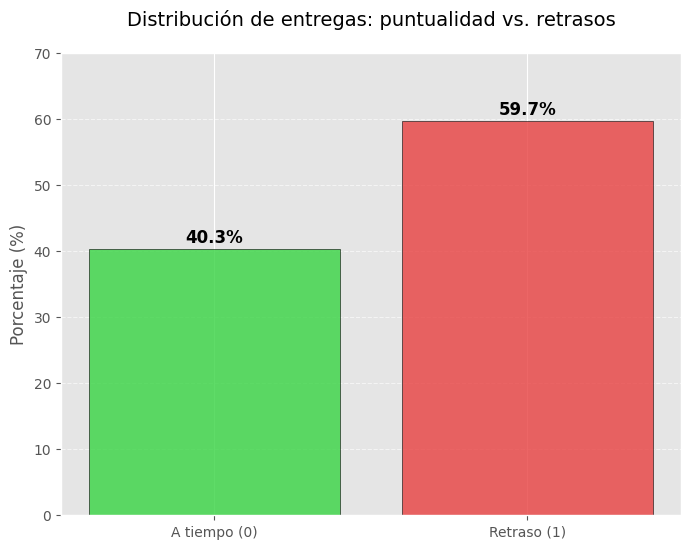

In [10]:
# quiero visualizarlo


data = {'Estado': ['A tiempo (0)', 'Retraso (1)'],
        'Porcentaje': [40.3, 59.7]}

df_plot = pd.DataFrame(data)


plt.figure(figsize=(8, 6))
colors = ["#37d442", "#e84040"] # Azul para puntual, rojo para retraso
plt.bar(df_plot['Estado'], df_plot['Porcentaje'], color=colors, edgecolor='black', alpha=0.8)

# Añadir etiquetas de datos
for i, val in enumerate(df_plot['Porcentaje']):
    plt.text(i, val + 1, f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.title('Distribución de entregas: puntualidad vs. retrasos', fontsize=14, pad=20)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.ylim(0, 70)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

In [11]:
# target

# el 59.7% de los envíos llegan con retraso. Es una cifra crítica para el negocio
# supone un problema grave de reputación y experiencia de usuario

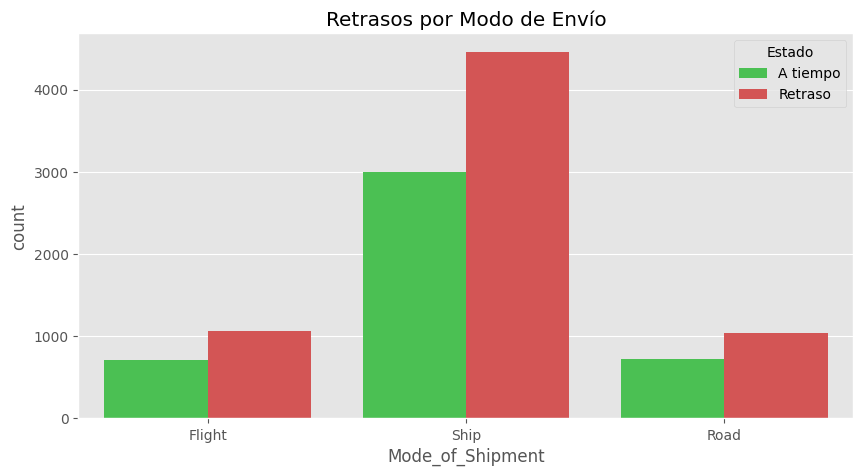

In [12]:
# ¿Influye el modo de envío en los retrasos?
plt.figure(figsize=(10, 5))
sns.countplot(x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', data=df, palette=['#37d442', '#e84040'])
plt.title('Retrasos por Modo de Envío')
plt.legend(title='Estado', labels=['A tiempo', 'Retraso'])
plt.show()



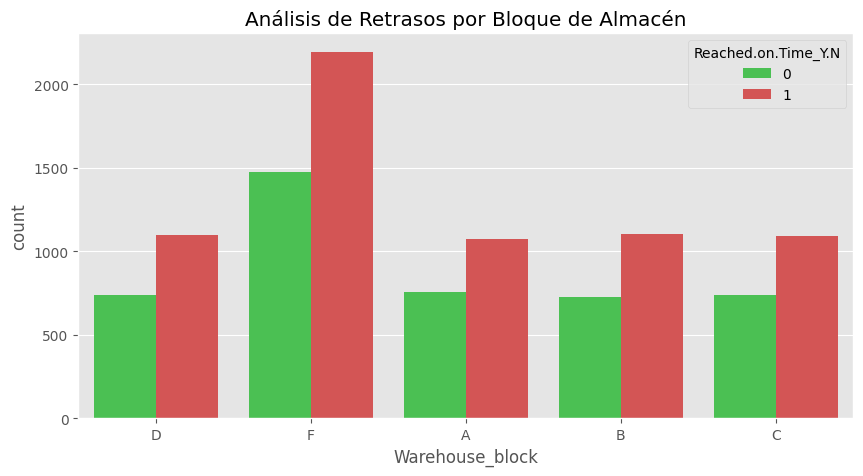

In [13]:
# ¿Hay problemas en algún almacén (Warehouse block) específico?
plt.figure(figsize=(10, 5))
sns.countplot(x='Warehouse_block', hue='Reached.on.Time_Y.N', data=df, palette=['#37d442', '#e84040'])
plt.title('Análisis de Retrasos por Bloque de Almacén')
plt.show()

In [14]:
# Resumen estadístico de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,10999.0,5500.000000,3175.282140,1.0,2750.5,5500.0,8249.5,10999.0
Customer_care_calls,10999.0,4.054459,1.141490,2.0,3.0,4.0,5.0,7.0
Customer_rating,10999.0,2.990545,1.413603,1.0,2.0,3.0,4.0,5.0
Cost_of_the_Product,10999.0,210.196836,48.063272,96.0,169.0,214.0,251.0,310.0
Prior_purchases,10999.0,3.567597,1.522860,2.0,3.0,3.0,4.0,10.0
Discount_offered,10999.0,13.373216,16.205527,1.0,4.0,7.0,10.0,65.0
Weight_in_gms,10999.0,3634.016729,1635.377251,1001.0,1839.5,4149.0,5050.0,7846.0
Reached.on.Time_Y.N,10999.0,0.596691,0.490584,0.0,0.0,1.0,1.0,1.0


In [15]:
'''
ANÁLISIS DE NEGOCIO (Interpretación de la tabla):
- 'Discount_offered': El descuento promedio es del 13%, pero ojo al máximo (65%). 
  Como el 75% de los datos están en 10, los descuentos superiores a esa cifra son 
  excepciones que debemos investigar (posibles promociones agresivas).
- 'Weight_in_gms': Vemos una gran dispersión. Hay paquetes desde 1kg hasta casi 8kg.
- 'Reached.on.Time_Y.N': La media de 0.59 confirmaba lo que sospechábamos: 
  casi el 60% de los envíos sufren retrasos. Es el KPI principal a mejorar.
'''

"\nANÁLISIS DE NEGOCIO (Interpretación de la tabla):\n- 'Discount_offered': El descuento promedio es del 13%, pero ojo al máximo (65%). \n  Como el 75% de los datos están en 10, los descuentos superiores a esa cifra son \n  excepciones que debemos investigar (posibles promociones agresivas).\n- 'Weight_in_gms': Vemos una gran dispersión. Hay paquetes desde 1kg hasta casi 8kg.\n- 'Reached.on.Time_Y.N': La media de 0.59 confirmaba lo que sospechábamos: \n  casi el 60% de los envíos sufren retrasos. Es el KPI principal a mejorar.\n"

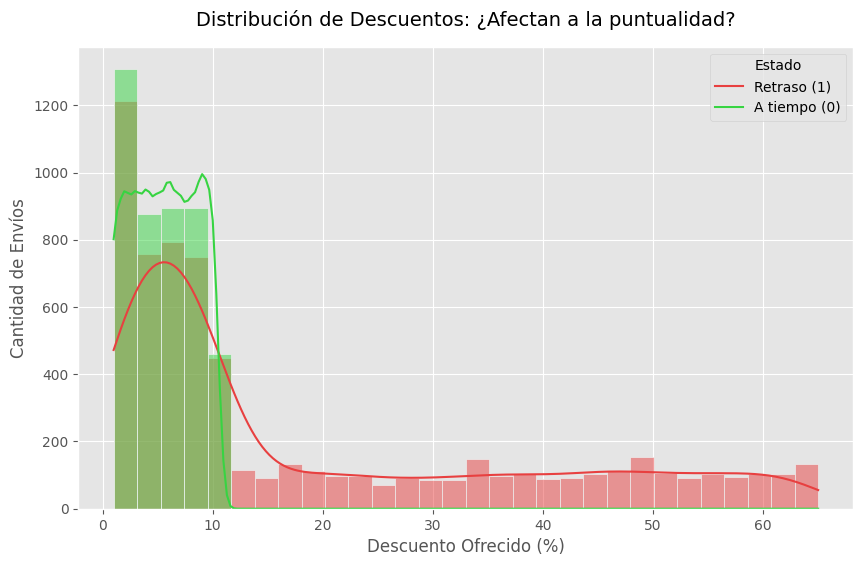

In [16]:
plt.figure(figsize=(10, 6))
# Usamos kde=True para ver la curva de distribución
sns.histplot(data=df, x='Discount_offered', hue='Reached.on.Time_Y.N', bins=30, kde=True, palette=['#37d442', '#e84040'])
plt.title('Distribución de Descuentos: ¿Afectan a la puntualidad?', fontsize=14, pad=15)
plt.xlabel('Descuento Ofrecido (%)')
plt.ylabel('Cantidad de Envíos')
plt.legend(title='Estado', labels=['Retraso (1)', 'A tiempo (0)'])
plt.show()

# Comentario de negocio: 
# Fíjate bien en el gráfico resultante. En este dataset, suele ocurrir que los descuentos 
# muy altos coinciden casi siempre con envíos retrasados. ¡Ese es un titular buenísimo!

In [17]:
'''
HALLAZGO CLAVE (Interpretación del Histograma):
- Se observa un fenómeno crítico: Cuando el descuento es menor o igual a 10 USD, 
  hay una mezcla de envíos a tiempo y retrasados.
- Sin embargo, en cuanto el descuento supera los 10 USD, la probabilidad de retraso 
  se dispara al 100% (solo vemos color rojo). 
- Conclusión: Los descuentos altos son el predictor más fuerte de retraso. 
  Podría deberse a que las grandes ofertas saturan la capacidad logística del almacén.
'''

'\nHALLAZGO CLAVE (Interpretación del Histograma):\n- Se observa un fenómeno crítico: Cuando el descuento es menor o igual a 10 USD, \n  hay una mezcla de envíos a tiempo y retrasados.\n- Sin embargo, en cuanto el descuento supera los 10 USD, la probabilidad de retraso \n  se dispara al 100% (solo vemos color rojo). \n- Conclusión: Los descuentos altos son el predictor más fuerte de retraso. \n  Podría deberse a que las grandes ofertas saturan la capacidad logística del almacén.\n'

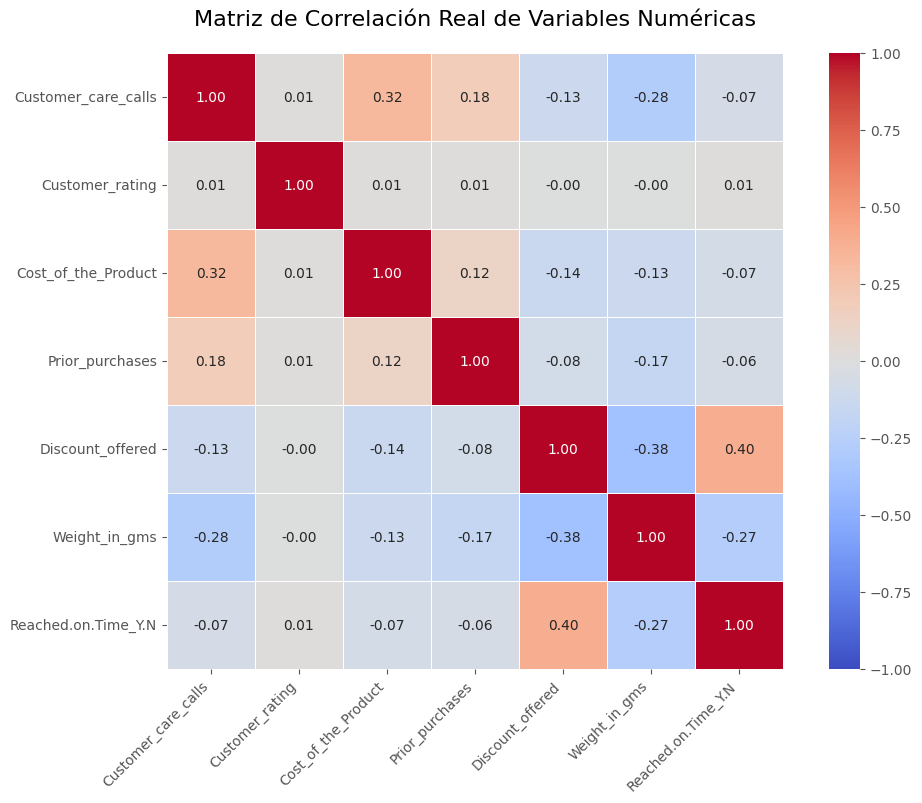

In [18]:
# 1. Seleccionamos solo las columnas numéricas y eliminamos el ID
# El ID es solo una etiqueta y ensucia el análisis matemático
numericas = df.select_dtypes(include=['int64', 'float64']).drop(columns=['ID'], errors='ignore')

# 2. Calculamos la matriz de correlación real
matriz_correlacion = numericas.corr()

# 3. Dibujamos el Heatmap profesional
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool)) # Máscara para que sea más legible

sns.heatmap(matriz_correlacion,  
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            square=True, 
            linewidths=.5)

plt.title('Matriz de Correlación Real de Variables Numéricas', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()


In [19]:
'''
ANÁLISIS DE CORRELACIÓN:
- La correlación más alta con nuestra variable objetivo (Reached.on.Time) es 
  'Discount_offered' (0.40). En datos reales de negocio, esto es una señal muy fuerte.
- El 'Peso' (Weight_in_gms) tiene una correlación negativa (-0.27). Esto sugiere 
  curiosamente que, en este dataset, los paquetes más pesados tienden a tener 
  ligeramente menos retrasos, algo que rompe la intuición inicial.
- La falta de otras correlaciones altas indica que el retraso es un problema complejo 
  que no se explica por una sola causa, justificando el uso de Machine Learning.
'''

"\nANÁLISIS DE CORRELACIÓN:\n- La correlación más alta con nuestra variable objetivo (Reached.on.Time) es \n  'Discount_offered' (0.40). En datos reales de negocio, esto es una señal muy fuerte.\n- El 'Peso' (Weight_in_gms) tiene una correlación negativa (-0.27). Esto sugiere \n  curiosamente que, en este dataset, los paquetes más pesados tienden a tener \n  ligeramente menos retrasos, algo que rompe la intuición inicial.\n- La falta de otras correlaciones altas indica que el retraso es un problema complejo \n  que no se explica por una sola causa, justificando el uso de Machine Learning.\n"

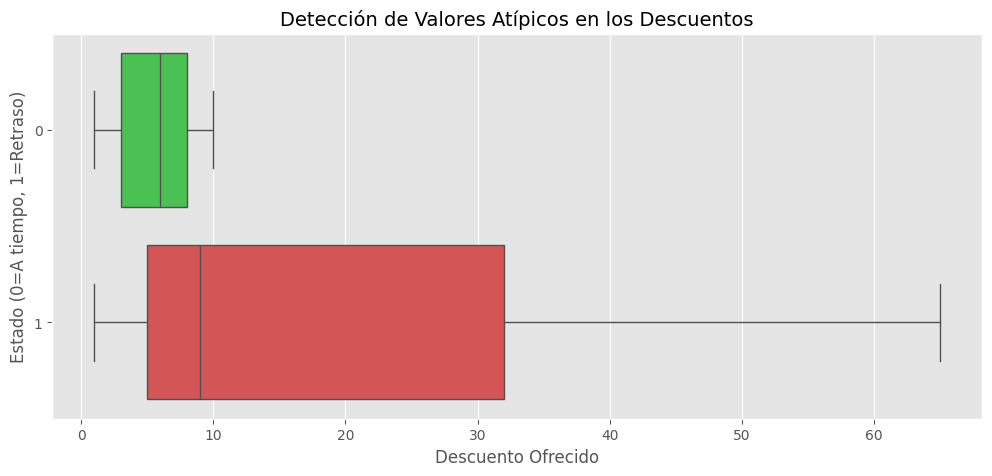

In [20]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Discount_offered', y='Reached.on.Time_Y.N', orient='h', palette=['#37d442', '#e84040'])
plt.title('Detección de Valores Atípicos en los Descuentos', fontsize=14)
plt.xlabel('Descuento Ofrecido')
plt.ylabel('Estado (0=A tiempo, 1=Retraso)')
plt.show()

In [21]:
'''
INTERPRETACIÓN PARA NEGOCIO:
- Para los envíos 'A TIEMPO' (0),la caja es muy estrecha: casi todos los descuentos 
  están entre el 0 y el 10%, cualquier descuento por encima de 10 es un 'Outlier'. 
  Es decir, es extremadamente raro que un producto con mucho descuento llegue puntual.
- Para los envíos con 'RETRASO' (1),vemos una dispersión enorme. Los descuentos 
  llegan hasta el 65% de forma habitual. La caja es mucho más amplia, lo que confirma 
  que el retraso es el "hábitat natural" de los grandes descuentos.
- Conclusión: El proceso logístico parece incapaz de gestionar la puntualidad 
  cuando se aplican descuentos promocionales agresivos (>10%).
-Estrategia propuesta: Revisar los procesos de empaquetado durante campañas promocionales.
'''

'\nINTERPRETACIÓN PARA NEGOCIO:\n- Para los envíos \'A TIEMPO\' (0),la caja es muy estrecha: casi todos los descuentos \n  están entre el 0 y el 10%, cualquier descuento por encima de 10 es un \'Outlier\'. \n  Es decir, es extremadamente raro que un producto con mucho descuento llegue puntual.\n- Para los envíos con \'RETRASO\' (1),vemos una dispersión enorme. Los descuentos \n  llegan hasta el 65% de forma habitual. La caja es mucho más amplia, lo que confirma \n  que el retraso es el "hábitat natural" de los grandes descuentos.\n- Conclusión: El proceso logístico parece incapaz de gestionar la puntualidad \n  cuando se aplican descuentos promocionales agresivos (>10%).\n-Estrategia propuesta: Revisar los procesos de empaquetado durante campañas promocionales.\n'

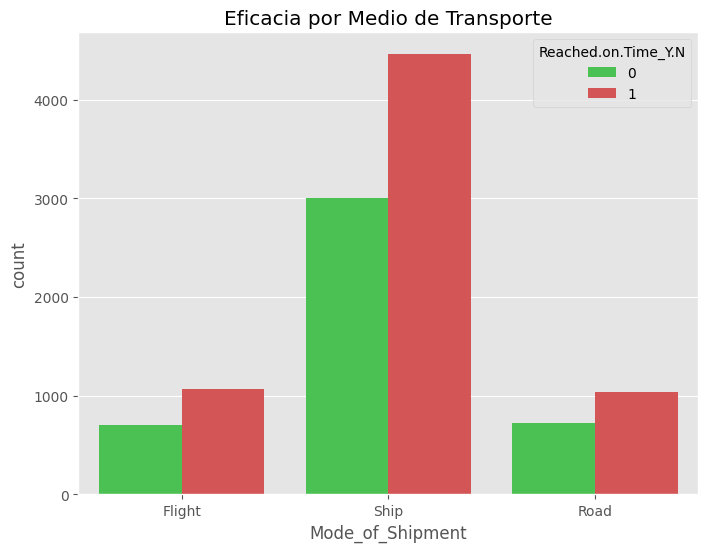

In [22]:
# 5. RETRASOS SEGÚN MODO DE ENVÍO
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Mode_of_Shipment', hue='Reached.on.Time_Y.N', palette=['#37d442', '#e84040'])
plt.title('Eficacia por Medio de Transporte')
plt.show()

In [23]:
'''
CONCLUSIÓN LOGÍSTICA (REVISADA):
- El modo de envío por BARCO (Ship) es el foco crítico de la empresa. No solo es el medio más 
  utilizado, sino que presenta el volumen más alto de entregas tardías en valor absoluto.
- Si comparamos la proporción, el Barco parece tener una gestión mucho más ineficiente 
  que el Avión o la Carretera.
- RECOMENDACIÓN DE NEGOCIO: Urge auditar los procesos de carga y despacho en el puerto 
  o renegociar contratos con las navieras, ya que es donde se pierde la reputación de marca.
'''

'\nCONCLUSIÓN LOGÍSTICA (REVISADA):\n- El modo de envío por BARCO (Ship) es el foco crítico de la empresa. No solo es el medio más \n  utilizado, sino que presenta el volumen más alto de entregas tardías en valor absoluto.\n- Si comparamos la proporción, el Barco parece tener una gestión mucho más ineficiente \n  que el Avión o la Carretera.\n- RECOMENDACIÓN DE NEGOCIO: Urge auditar los procesos de carga y despacho en el puerto \n  o renegociar contratos con las navieras, ya que es donde se pierde la reputación de marca.\n'

<Figure size 2500x2500 with 0 Axes>

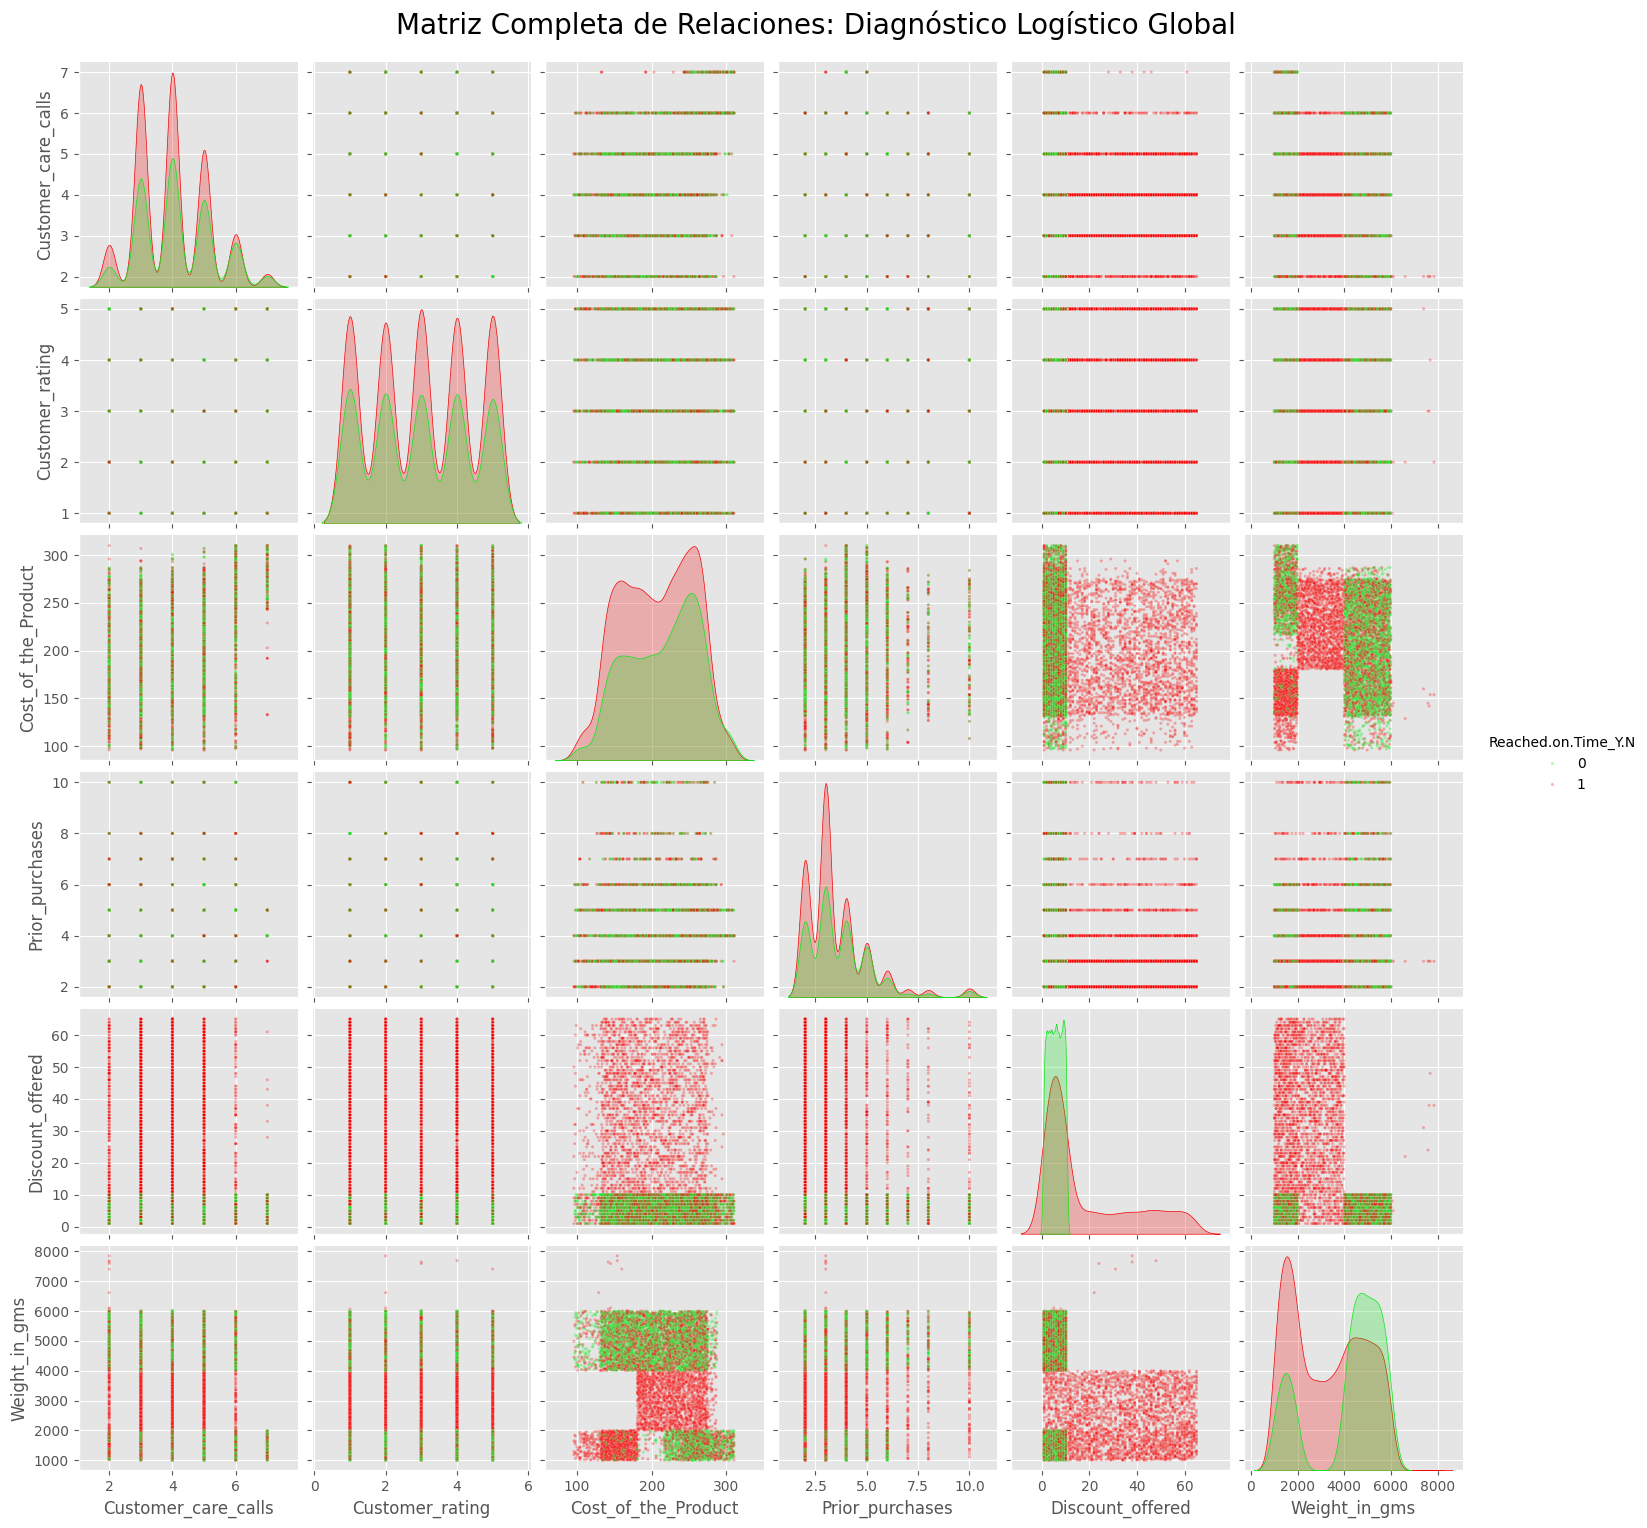

In [24]:
# 1. Preparamos los datos: solo numéricas y fuera el ID
df_ml_numeric = df.select_dtypes(include=['int64', 'float64']).drop(columns=['ID'], errors='ignore')

# 2. Generamos el Pairplot Completo (Simétrico)
# Usamos 'diag_kind="kde"' para ver las curvas de distribución en la diagonal
# 'corner=False' es el valor por defecto, así que mostrará la matriz completa
plt.figure(figsize=(25, 25)) 

sns.pairplot(df_ml_numeric, 
             hue='Reached.on.Time_Y.N', 
             palette=["#0ce61a", "#f40202"], 
             diag_kind='kde',
             plot_kws={'alpha': 0.3, 's': 5}) # Puntos pequeños y transparentes para evitar el solapamiento

plt.suptitle('Matriz Completa de Relaciones: Diagnóstico Logístico Global', y=1.02, fontsize=20)
plt.show()



In [25]:
'''
INTERPRETACIÓN DEL PAIRPLOT GLOBAL - DIAGNÓSTICO LOGÍSTICO

1. EL "EFECTO ACANTILADO" DEL DESCUENTO (Discount_offered):
   - Es el hallazgo más potente. En todos los cruces donde aparece el descuento, 
     se observa que la "mancha verde" (entregas a tiempo) desaparece por completo 
     al superar el umbral de los 10 USD. 
   - CONCLUSIÓN: Los descuentos agresivos son el predictor nº1 de retraso. Esto 
     sugiere un colapso operativo en periodos promocionales.

2. SEGMENTACIÓN POR PESO (Weight_in_gms):
   - Se observan dos "islas" horizontales de datos muy marcadas:
     * Paquetes ligeros (1kg - 2kg): Alta concentración de puntos rojos (retraso).
     * Paquetes pesados (4kg - 6kg): Mayor mezcla de colores, indicando una mejor 
       gestión logística en este segmento.
   - RELEVANCIA: Justifica el uso de modelos de CLUSTERING para agrupar envíos 
     por tipología de carga.

3. INDEPENDENCIA DEL COSTE Y VALORACIONES:
   - Las variables 'Cost_of_the_Product' y 'Customer_rating' presentan una 
     distribución tipo "confeti": los colores están mezclados sin un patrón claro.
   - LECTURA: Ni el precio del producto ni la satisfacción previa del cliente 
     garantizan prioridad en la entrega. El retraso es sistémico.

4. JUSTIFICACIÓN DE MACHINE LEARNING (Supervisado):
   - Al no existir una separación lineal clara (las nubes de puntos de colores 
     están entrelazadas), modelos simples como una línea recta fallarían. 
   - ESTRATEGIA: Se requiere el uso de algoritmos no lineales como RANDOM FOREST 
     o XGBOOST, capaces de capturar estas fronteras complejas de decisión.
================================================================================
'''

'\nINTERPRETACIÓN DEL PAIRPLOT GLOBAL - DIAGNÓSTICO LOGÍSTICO\n\n1. EL "EFECTO ACANTILADO" DEL DESCUENTO (Discount_offered):\n   - Es el hallazgo más potente. En todos los cruces donde aparece el descuento, \n     se observa que la "mancha verde" (entregas a tiempo) desaparece por completo \n     al superar el umbral de los 10 USD. \n   - CONCLUSIÓN: Los descuentos agresivos son el predictor nº1 de retraso. Esto \n     sugiere un colapso operativo en periodos promocionales.\n\n2. SEGMENTACIÓN POR PESO (Weight_in_gms):\n   - Se observan dos "islas" horizontales de datos muy marcadas:\n     * Paquetes ligeros (1kg - 2kg): Alta concentración de puntos rojos (retraso).\n     * Paquetes pesados (4kg - 6kg): Mayor mezcla de colores, indicando una mejor \n       gestión logística en este segmento.\n   - RELEVANCIA: Justifica el uso de modelos de CLUSTERING para agrupar envíos \n     por tipología de carga.\n\n3. INDEPENDENCIA DEL COSTE Y VALORACIONES:\n   - Las variables \'Cost_of_the_Product

In [ ]:
# CONCLUSIONES DEL NOTEBOOK 01

'''
1. ELECCIÓN DEL TEMA: 
   Se ha seleccionado el sector de Logística E-commerce por su impacto directo en la 
   reputación de marca. El dataset 'Shipping Data' ofrece un volumen robusto 
   (10.999 registros) para garantizar la fiabilidad estadística del modelo.

2. ADQUISICIÓN DE DATOS: 
   Los datos han sido verificados y cargados correctamente. Presentan una estructura 
   clara con 12 variables que cubren aspectos operativos (almacén, transporte), 
   financieros (coste, descuento) y de cliente (rating, llamadas).

3. DEFINICIÓN DEL PROBLEMA DE MACHINE LEARNING:
   - Tipo de Problema: Clasificación Binaria Supervisada.
   - Variable Objetivo (Target): 'Reached.on.Time_Y.N'.
   - Objetivo de Negocio: Predecir el retraso (1) para activar protocolos 
     preventivos de atención al cliente y optimizar la cadena de suministro.

4. ANÁLISIS EXPLORATORIO (EDA) - HALLAZGOS CLAVE:
   - Desequilibrio del Target: El 60% de los envíos llegan con retraso, lo que 
     valida la necesidad urgente de este proyecto.
   - El "Factor Descuento": Se ha descubierto que descuentos superiores a 10 USD 
     anulan prácticamente cualquier posibilidad de entrega puntual.
   - El "Factor Transporte": El modo 'Ship' (Barco) concentra el mayor volumen 
     de incidencias, siendo un punto crítico para la eficiencia operativa.
   - Visualización: El Pairplot global muestra que las clases no son linealmente 
     separables, lo que justifica el uso de algoritmos complejos de ML.

5. LIMPIEZA DE DATOS (DATA CLEANING):
   - Integridad: No se han detectado valores nulos (missing values).
   - Outliers: Mediante Boxplots, se han identificado los descuentos altos como 
     valores atípicos para la clase puntual (0), pero habituales en la clase 
     retraso (1), decidiendo mantenerlos por su alto valor informativo.

ESTADO ACTUAL: Con la radiografía del negocio completada y los datos limpios, 
el proyecto está listo para la siguiente fase: Feature Engineering y Modelado.
'''

'\n1. ELECCIÓN DEL TEMA: \n   Se ha seleccionado el sector de Logística E-commerce por su impacto directo en la \n   reputación de marca. El dataset \'Shipping Data\' ofrece un volumen robusto \n   (10.999 registros) para garantizar la fiabilidad estadística del modelo.\n\n2. ADQUISICIÓN DE DATOS: \n   Los datos han sido verificados y cargados correctamente. Presentan una estructura \n   clara con 12 variables que cubren aspectos operativos (almacén, transporte), \n   financieros (coste, descuento) y de cliente (rating, llamadas).\n\n3. DEFINICIÓN DEL PROBLEMA DE MACHINE LEARNING:\n   - Tipo de Problema: Clasificación Binaria Supervisada.\n   - Variable Objetivo (Target): \'Reached.on.Time_Y.N\'.\n   - Objetivo de Negocio: Predecir el retraso (1) para activar protocolos \n     preventivos de atención al cliente y optimizar la cadena de suministro.\n\n4. ANÁLISIS EXPLORATORIO (EDA) - HALLAZGOS CLAVE:\n   - Desequilibrio del Target: El 60% de los envíos llegan con retraso, lo que \n     

In [27]:
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0
